<center><h1>Numerical nonlinear systems of equation</h1></center>
<center><h3>The method of steepest descent</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

Two molecules, where one is modeled as a single sphere and the other as a pair of spheres joined by a rigid link, bind to each other by adopting a configuration which minimises an interaction energy between them. This energy describes how the two molecules are attracted to each other, but also experience repulsion if they get too close. We suppose the interaction energy $E$ is a function of the separation distance $r$ and orientation angle $\theta$,

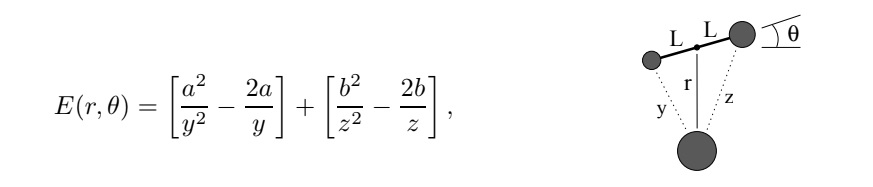

In [2]:
Image('molecules.jpg')

where $y = (L*cos(\theta))^{2} + (r - sin(\theta))^{2}$, $z = (L*cos(\theta))^{2} + (r + sin(\theta))^{2}$, and $a$, $b$ and $L$ are constants. Here the method of steepest descent is used to find configurations $(r, \theta)$ that minimises $E$. For concreteness, we assume $\{a, b, L\} = \{1.0, 1.5, 0.7\}$ in appropriate units.

Consider the function $g(x) = E(r, \theta)$, where $x = (r, \theta)$, and find an expression for the gradient $\nabla g(x)$. Use the steepest descent to find a minimum starting from at least three different choices of $x^{(0)}$. Assume the region of interest is $0 < r \leq 5$ and $-\pi \leq \theta \leq \pi$ and iterate until $||\nabla g(x^{(k)})||_{2} < 10^{-6}$. Report the configuration $(r, \theta)$ and energy $E$ for each minimum point found. Do different choices of $x^{(0)}$ lead to genuinely different solutions, or do they all lead to a single solution up to the tolerance?

Note: $E$ becomes infinite if the molecules get too close to each other, so avoid initial guesses with small $r$. Also avoid using large step sizes, so use $\alpha_{init} = 0.2$.

In [3]:
def energy(xk):
    a = 1
    b = 1.5
    L = 0.7
    
    y = (L*np.cos(xk[1]))**2 + (xk[0] - L*np.sin(xk[1]))**2
    z = (L*np.cos(xk[1]))**2 + (xk[0] + L*np.sin(xk[1]))**2
    g = ((a**2/y**2) - ((2*a)/y)) + ((b**2/z**2) - ((2*b)/z))
    return g

def grad_energy(xk):
    a = 1
    b = 1.5
    L = 0.7
    dg = [0, 0]
    
    dg[0] = -((4 * a**2 * (xk[0]-L*np.sin(xk[1])))/(L**2 * np.cos(xk[1])**2 + (xk[0] - L*np.sin(xk[1]))**2)**3) + ((4 * a * (xk[0] - L*np.sin(xk[1])))/(L**2 * np.cos(xk[1])**2 + (xk[0] - L*np.sin(xk[1]))**2)**2) - ((4 * b**2 * (L*np.sin(xk[1]) + xk[0])) / (L**2 * (np.cos(xk[1]))**2 + (L*np.sin(xk[1]) + xk[0])**2)**3) + ((4 * b * (L*np.sin(xk[1])+xk[0]))/ (L**2 * (np.cos(xk[1]))**2 + (L*np.sin(xk[1]) + xk[0])**2)**2)
    dg[1] = 4 * L * xk[0] * np.cos(xk[1]) * ((a**2/(L**2 - 2 * L * xk[0] * np.sin(xk[1]) + xk[0]**2)**3) - (a/(L**2 - 2 * L * xk[0] * np.sin(xk[1]) + xk[0]**2))
            + ((b * (-b + L**2 + 2 * L * xk[0] * np.sin(xk[1])
            + xk[0]**2))/(L**2 + 2 * L * xk[0] * np.sin(xk[1]) + xk[0]**2)**3))
    return dg

def steepest(xk, a_init, maxAlphaSrch, maxIter, tol):
    iter = 0
    gk = energy(xk)
    dgk = grad_energy(xk)
    dgknorm = np.linalg.norm(dgk)
    
    while(iter < maxIter and dgknorm >= tol):
        ah = a_init
        xh = xk - np.dot((ah/dgknorm), dgk)
        gh = energy(xh)
        alphaSrch = 0
        while(alphaSrch < maxAlphaSrch and gh >= gk):
            ah = 0.5 * ah
            xh = xk - np.dot((ah/dgknorm), dgk)
            gh = energy(xh)
            alphaSrch += 1
        xk = xh
        gk = gh
        dgk = grad_energy(xk)
        dgknorm = np.linalg.norm(dgk)
        iter += 1
    
    print(f'Iterations needed: {iter}')
    print(f'Gradient norm: {dgknorm}')
    print(f'Approximate solution: {xh}')
    print(f'Approximate g-value: {gh}')

if __name__ == "__main__":
    xk = [3, 2]
    steepest(xk, 0.2, 20, 100, 1e-6)

Iterations needed: 65
Gradient norm: 8.442432291127026e-07
Approximate solution: [0.87177975 2.93529696]
Approximate g-value: -1.999999999999977


## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

## Useful links:
Quick definition:<br>
https://mathworld.wolfram.com/MethodofSteepestDescent.html